# Week 2 - Diagnostic and Descriptive Analysis

This notebook carries out the following steps
1. Read the pickle file
2. Add derived features of the returns on each loan
3. Visualize variables incl. returns
4. Explore returns by grade
5. Create multi-variable summaries
6. Run K-means on a relevant subset of the columns
7. Run PCA on a relevant subset of the columns
8. Save new pickle with the new return columns

Things for you to add
- Understand the derived returns and modify them as you see appropriate
- Explain the grades using other variables as best as you can
- Choose other/more variables for K-Means and PCA
- Try to find a K-means clustering (by picking the variables and value of K) that is highly correlated with the grades
- Interpret the clusters in the final clustering by naming them (Find prototype names and not stereotype names)
- Interpret loadings on PCA and relate them to correlation plot among the vars
- (Optional) Run PCA on the subset of loans of a specific grade and examine top PCs. Use this to interpret the grades

Prepare your presentation. Your presentation should contain at most 6 slides.  Add an extra slide at the end if you tried the BONUS.
1. Begin by stating the objective of the presentation and what your objective is. Which questions do you seek to answer?  Which return method do you think makes the most sense and will you use for the rest of the project?

2. (3) Comment on the clusters that you obtained. Which variables did you use? Are they correlated with grades? Give a verbal interpretation of the clusters. Giving each a name might help.Support these comments with plots and/or tables. Why might clusters be useful for the overall project?

4. Did you get any interesting insight from the PCA analysis? Are the PC's able to capture high variance? Do you think they will be useful in a further part of the project? If so, how?

5. State your conclusions. What is the main idea you wish to convey with the presentation? Do you think the findings from this script will be useful to solve the problem? What are the main takeaways of the analysis you performed?

BONUS
- PCA is sometimes hard to interpret. Using SPARSE PCA can help interpretation. Read about this technique and implement it. You might want to use the package elasticnet. Give an intuitive interpretation of the sparse components that you obtained. What are the drawbacks of sparse PCA?

- Implement clusters using a different clustering method, such as Hierarchical clustering. Are the clusters correlated with grades? How do you think the grades were originally derived?



In [1]:
import pandas as pd
import os
from sys import platform
import matplotlib.pyplot as plt
import datetime
import numpy as np
import pickle
import seaborn
import time

## Step 1 - Read pickle file from Week 1

In [2]:
### Read the data and features from the pickle
final_data, discrete_features, continuous_features = pickle.load( open( "/Users/hrishikeshharishkumar/CMU Mini 1 - Fall 2023 - Business Value through Integrative Analytics/Update 1: Business and Data Understanding/PickleData/clean_data4.pickle", "rb" ) )
#final_data, discrete_features, continuous_features = pickle.load( open( "./PickleData/201213clean_data.pickle", "rb" ) )

In [4]:
final_data

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,tot_cur_bal,bc_util,funded_amnt_inv,inq_last_6mths,pct_tl_nvr_dlq,total_acc,sub_grade,acc_now_delinq,tot_coll_amt,zip_code
4,10129506,20800.0,20800.0,36 months,13.53,706.16,B,10+ years,RENT,81500.0,...,23473.0,54.6,20800.0,2.0,90.2,41.0,B5,0.0,0.0,100xx
6,10179520,3000.0,3000.0,36 months,12.85,100.87,B,10+ years,RENT,25000.0,...,19530.0,52.3,3000.0,0.0,91.3,26.0,B4,0.0,154.0,322xx
7,10139658,12000.0,12000.0,36 months,13.53,407.40,B,10+ years,RENT,40000.0,...,13605.0,79.6,12000.0,0.0,81.2,32.0,B5,0.0,15386.0,871xx
10,10148122,12000.0,12000.0,36 months,7.62,373.94,A,3 years,MORTGAGE,96500.0,...,200314.0,83.5,12000.0,0.0,100.0,30.0,A3,0.0,0.0,782xx
12,10149577,28000.0,28000.0,36 months,7.62,872.52,A,5 years,MORTGAGE,325000.0,...,799592.0,67.1,28000.0,1.0,100.0,31.0,A3,0.0,0.0,945xx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423742,9715141,6000.0,6000.0,36 months,15.61,209.79,C,7 years,RENT,27000.0,...,259863.0,69.0,6000.0,3.0,100.0,16.0,C4,0.0,0.0,913xx
423743,9695736,8525.0,8525.0,60 months,18.25,217.65,D,5 years,MORTGAGE,37536.0,...,116995.0,0.7,8525.0,0.0,84.6,26.0,D3,0.0,0.0,011xx
423744,9007579,18000.0,18000.0,36 months,7.90,563.23,A,3 years,RENT,90000.0,...,42592.0,17.4,17975.0,0.0,90.9,33.0,A4,0.0,0.0,212xx
423748,9684700,22000.0,22000.0,60 months,19.97,582.50,D,10+ years,MORTGAGE,78000.0,...,221830.0,54.4,22000.0,5.0,100.0,30.0,D5,0.0,0.0,377xx


## Step 2 - Calculate returns for each loan

In [5]:
### Define the names of the four returns we'll be calculating

ret_cols = ["ret_PESS", "ret_OPT", "ret_INTa", "ret_INTb", "ret_INTc"]

In [6]:
## Remove all rows for loans that were paid back on the days
# they were issued
final_data['loan_length'] = (final_data.last_pymnt_d - final_data.issue_d) / np.timedelta64(1, 'M')
n_rows = len(final_data)
final_data = final_data[final_data.loan_length != 0]
print("Removed " + str(n_rows - len(final_data)) + " rows")

Removed 33 rows


#### Return Method 2 (pessimistic)

In [7]:
# Calculate the return using a simple annualized profit margin
# Pessimistic fefinition (method 2)

final_data['term_num'] = final_data.term.str.extract('(\d+)',expand=False).astype(int)
final_data['ret_PESS'] = ( (final_data.total_pymnt - final_data.funded_amnt)
                                            / final_data.funded_amnt ) * (12 / final_data['term_num'])

/var/folders/w7/f6hf3dtd2x7499bzq7957z7r0000gn/T/ipykernel_78414/2841914929.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['term_num'] = final_data.term.str.extract('(\d+)',expand=False).astype(int)
/var/folders/w7/f6hf3dtd2x7499bzq7957z7r0000gn/T/ipykernel_78414/2841914929.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['ret_PESS'] = ( (final_data.total_pymnt - final_data.funded_amnt)


#### Return Method 1 (optimistic)

In [8]:
# Assuming that if a loan gives a positive return, we can
# immediately find a similar loan to invest in; if the loan
# takes a loss, we use method 2 to compute the return

final_data['ret_OPT'] = ( (final_data.total_pymnt - final_data.funded_amnt)
                                            / final_data.funded_amnt ) * (12 / final_data['loan_length'])
final_data.loc[final_data.ret_OPT < 0,'ret_OPT'] = final_data.ret_PESS[final_data.ret_OPT < 0]

/var/folders/w7/f6hf3dtd2x7499bzq7957z7r0000gn/T/ipykernel_78414/676985002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['ret_OPT'] = ( (final_data.total_pymnt - final_data.funded_amnt)


#### Return Method 3 (re-investment)

In [9]:
def ret_method_3(T, i):
    '''
    Given an investment time horizon (in months) and re-investment
    interest rate, calculate the return of each loan
    '''

    # Assuming that the total amount paid back was paid at equal
    # intervals during the duration of the loan, calculate the
    # size of each of these installment
    actual_installment = (final_data.total_pymnt - final_data.recoveries) / final_data['loan_length']

    # Assuming the amount is immediately re-invested at the prime
    # rate, find the total amount of money we'll have by the end
    # of the loan
    cash_by_end_of_loan = actual_installment * (1 - pow(1 + i, final_data.loan_length)) / ( 1 - (1 + i) )

    cash_by_end_of_loan = cash_by_end_of_loan + final_data.recoveries

    # Assuming that cash is then re-invested at the prime rate,
    # with monthly re-investment, until T months from the start
    # of the loan
    remaining_months = T - final_data['loan_length']
    final_return = cash_by_end_of_loan * pow(1 + i, remaining_months)

    # Find the percentage return
    return( (12/T) * ( ( final_return - final_data['funded_amnt'] ) / final_data['funded_amnt'] ) )

final_data['ret_INTa'] = ret_method_3(5*12, 0.001)
final_data['ret_INTb'] = ret_method_3(5*12, 0.0025)
final_data['ret_INTc'] = ret_method_3(5*12, 0.005)

/var/folders/w7/f6hf3dtd2x7499bzq7957z7r0000gn/T/ipykernel_78414/3174847521.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['ret_INTa'] = ret_method_3(5*12, 0.001)
/var/folders/w7/f6hf3dtd2x7499bzq7957z7r0000gn/T/ipykernel_78414/3174847521.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['ret_INTb'] = ret_method_3(5*12, 0.0025)
/var/folders/w7/f6hf3dtd2x7499bzq7957z7r0000gn/T/ipykernel_78414/3174847521.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [10]:
final_data.head()

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,acc_now_delinq,tot_coll_amt,zip_code,loan_length,term_num,ret_PESS,ret_OPT,ret_INTa,ret_INTb,ret_INTc
4,10129506,20800.0,20800.0,36 months,13.53,706.16,B,10+ years,RENT,81500.0,...,0.0,0.0,100xx,16.953120,36,0.050106,0.106401,0.042104,0.061342,0.096823
6,10179520,3000.0,3000.0,36 months,12.85,100.87,B,10+ years,RENT,25000.0,...,0.0,154.0,322xx,6.965235,36,0.020172,0.104260,0.024318,0.043948,0.080483
7,10139658,12000.0,12000.0,36 months,13.53,407.40,B,10+ years,RENT,40000.0,...,0.0,15386.0,871xx,20.994271,36,0.037772,0.064769,0.033844,0.051672,0.084439
10,10148122,12000.0,12000.0,36 months,7.62,373.94,A,3 years,MORTGAGE,96500.0,...,0.0,0.0,782xx,29.996509,36,0.038821,0.046590,0.033457,0.049593,0.079043
12,10149577,28000.0,28000.0,36 months,7.62,872.52,A,5 years,MORTGAGE,325000.0,...,0.0,0.0,945xx,7.983737,36,0.013702,0.061785,0.020101,0.039180,0.074655


## Step 3 - Visualize the variables

In [11]:
# Identify the type of each of these column
float_cols = ['loan_amnt', 'funded_amnt', 'installment', 'annual_inc',
                     'dti', 'revol_bal', 'delinq_2yrs', 'open_acc', 'pub_rec',
                      'total_pymnt', 'recoveries']
cat_cols = ['term', 'grade', 'emp_length', 'home_ownership',
                    'verification_status', 'loan_status', 'purpose']
perc_cols = ['int_rate', 'revol_util']
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d']

def visualize_columns():
    '''
    This function visualizes all columns
      - Box-and-whisker plots for continuous variables
      - Lists of distinct values for categorical columns
      - A timeline density for dates
    '''

    # Float columns
    for i in float_cols + perc_cols +ret_cols:
        # seaborn.boxplot(final_data[i])
        final_data.boxplot(i)

        # Print the three highest values
        highest_vals = sorted(final_data[i], reverse=True)[:3]
        smallest_val = min(final_data[i])
        # plt.text(smallest_val, -0.3, highest_vals[0])
        # plt.text(smallest_val, -0.2, highest_vals[1])
        # plt.text(smallest_val, -0.1, highest_vals[2])

        plt.show()

    # Categorical columns
    for i in cat_cols:
        print(i)
        print(str(len(set(final_data[i]))) + " distinct values")
        print(final_data[i].value_counts())
        print("")
        print("")

    # Date columns
    for i in date_cols:
        final_data[final_data[i].isnull() == False][i].apply(lambda x : str(x.year) +
                                                "-" + str(x.month)).value_counts(ascending = True).plot()
        plt.title(i + " (" + str(final_data[i].isnull().sum()) + " null values)")
        plt.show()

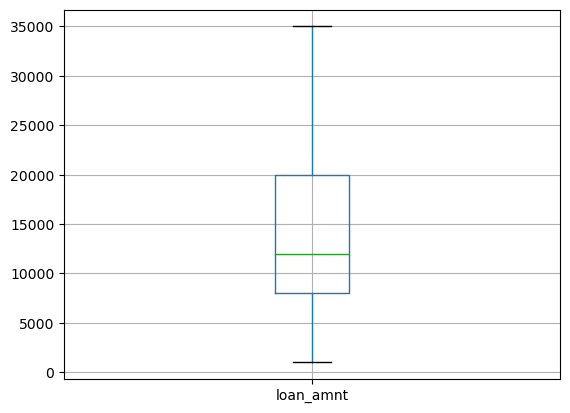

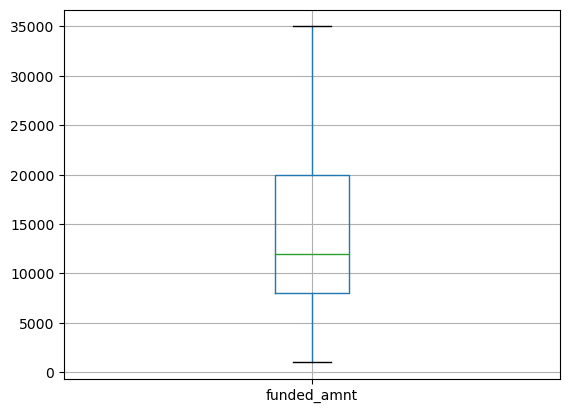

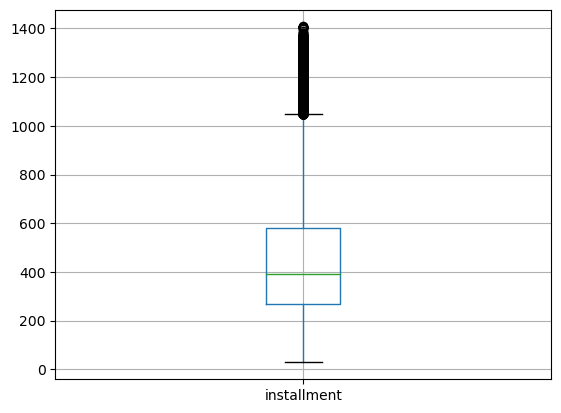

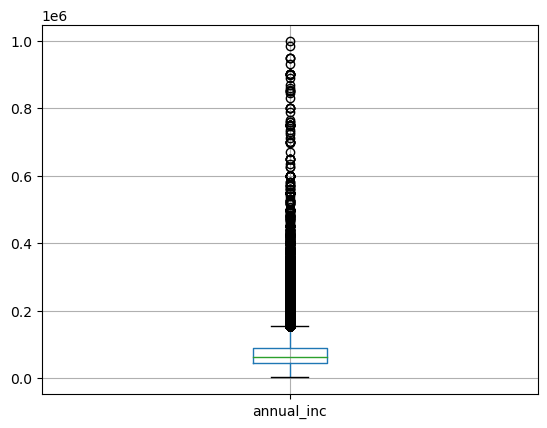

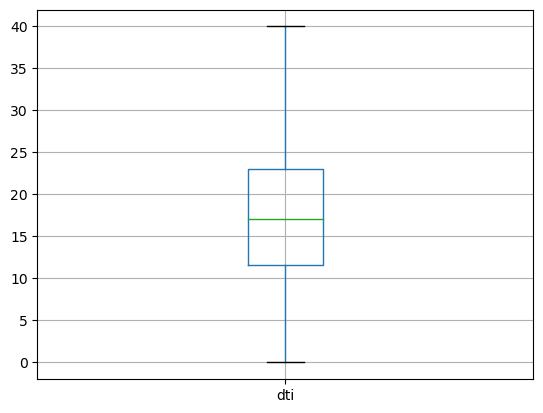

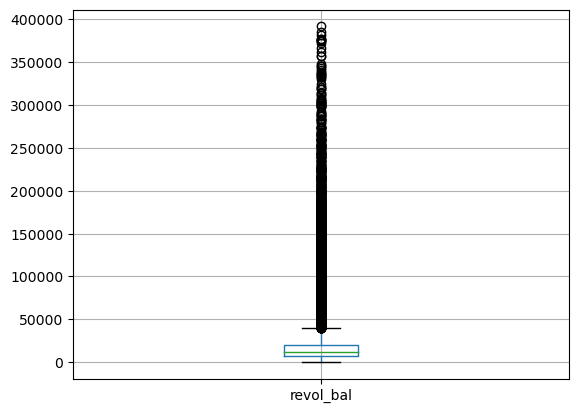

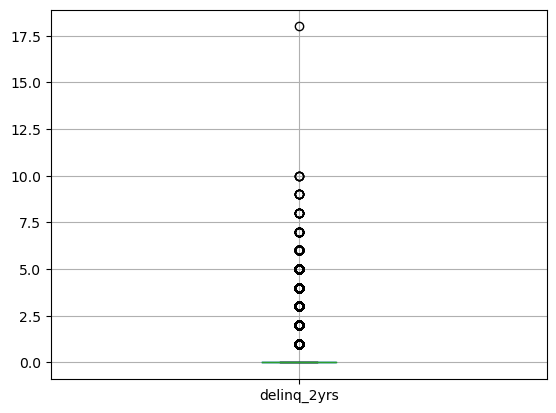

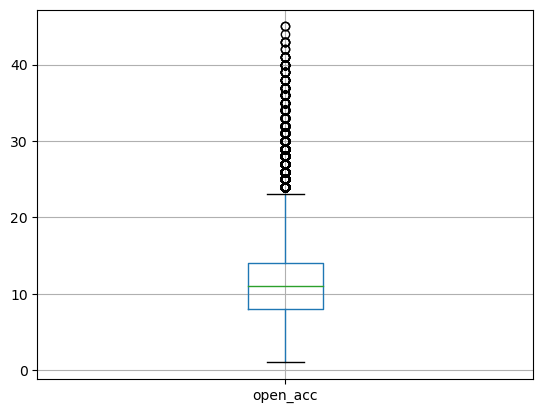

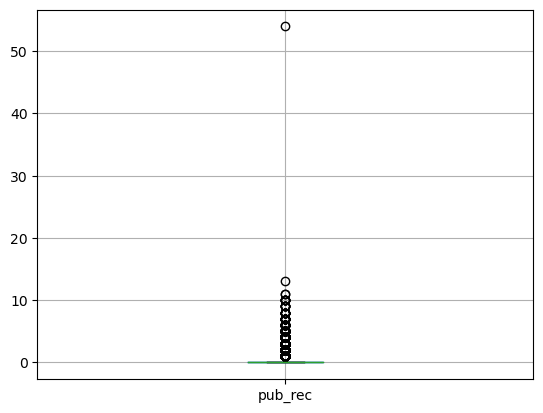

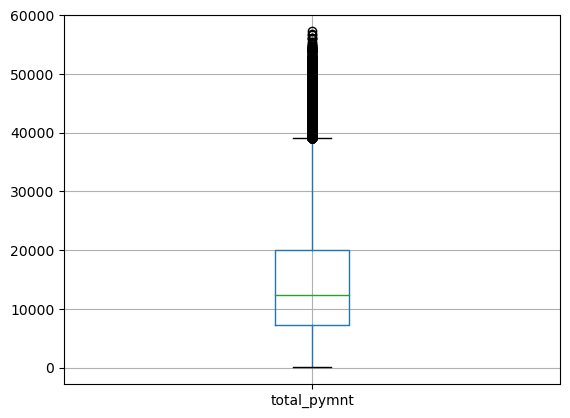

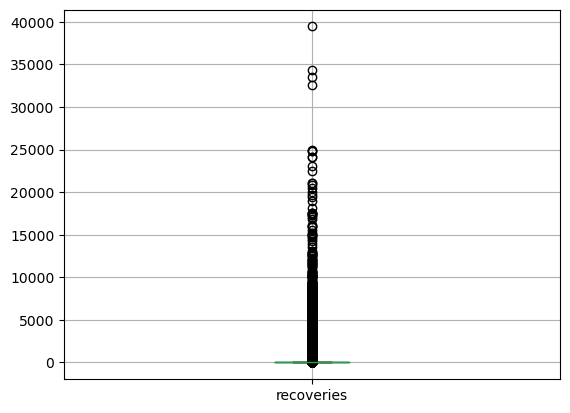

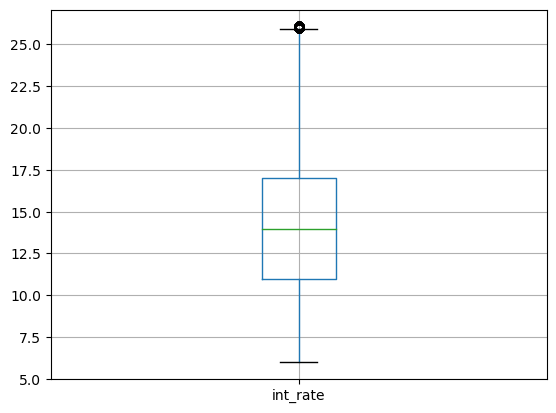

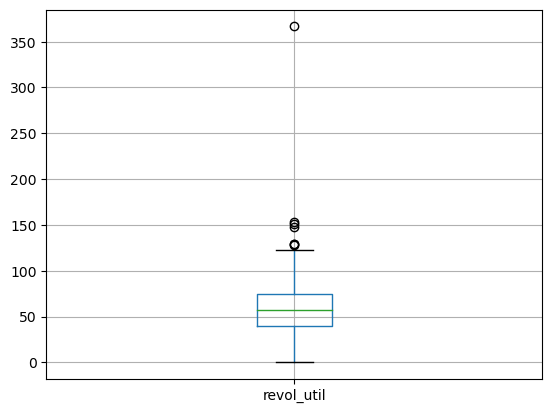

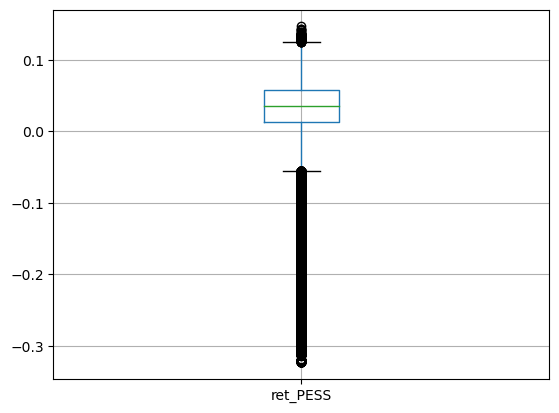

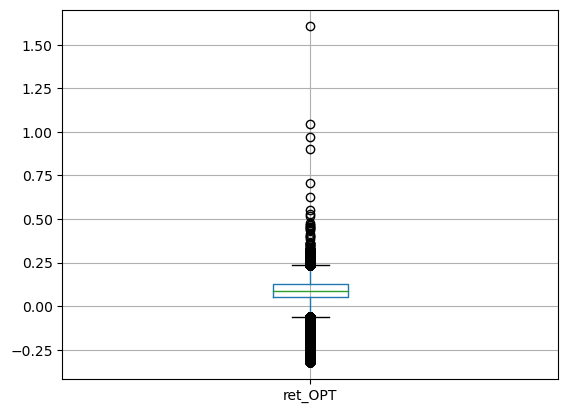

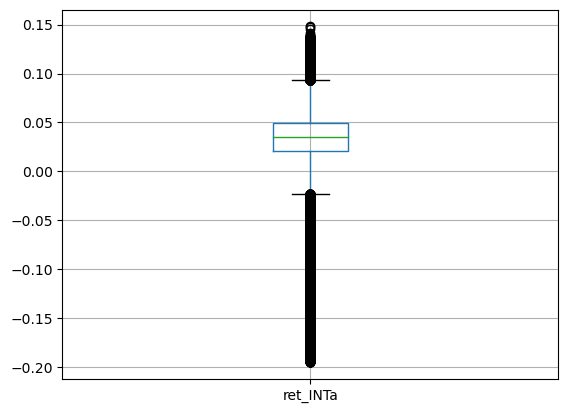

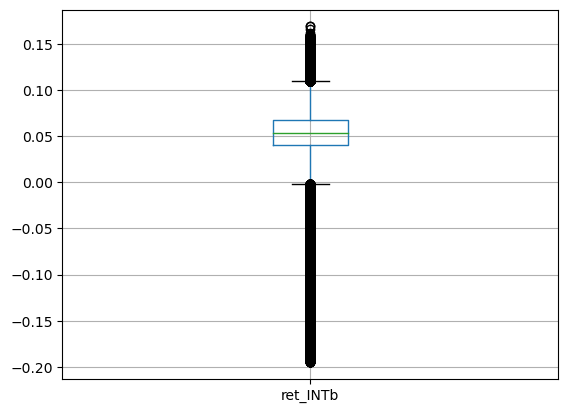

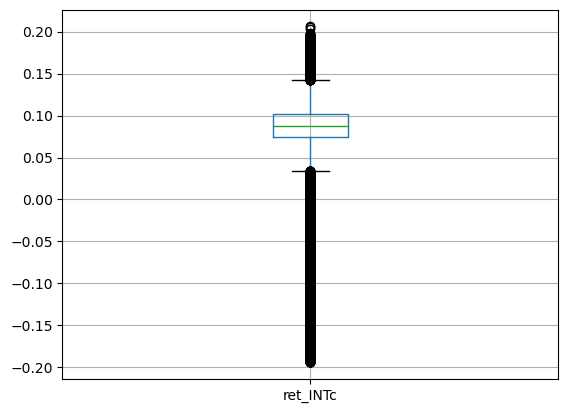

term
2 distinct values
 36 months    153278
 60 months     43249
Name: term, dtype: int64


grade
7 distinct values
B    60914
C    52663
D    32212
A    29373
E    14278
F     5745
G     1342
Name: grade, dtype: int64


emp_length
12 distinct values
10+ years    63075
2 years      17522
3 years      15346
< 1 year     14778
5 years      13304
1 year       12321
7 years      11652
6 years      11616
4 years      11097
8 years       9747
9 years       7721
Name: emp_length, dtype: int64


home_ownership
6 distinct values
MORTGAGE    100614
RENT         78879
OWN          16958
OTHER           41
NONE            34
ANY              1
Name: home_ownership, dtype: int64


verification_status
3 distinct values
Verified           76380
Not Verified       63188
Source Verified    56959
Name: verification_status, dtype: int64


loan_status
3 distinct values
Fully Paid     157817
Charged Off     38609
Default           101
Name: loan_status, dtype: int64


purpose
13 distinct values
debt_consol

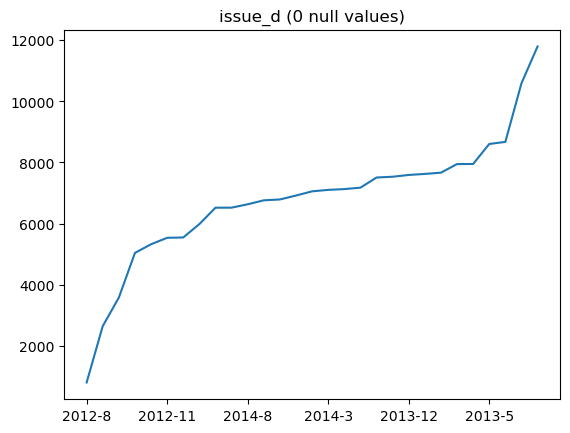

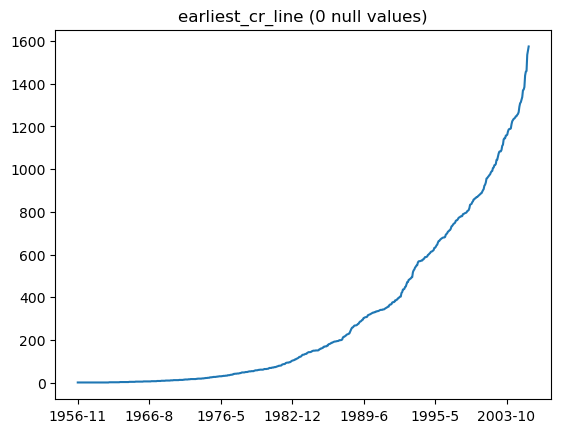

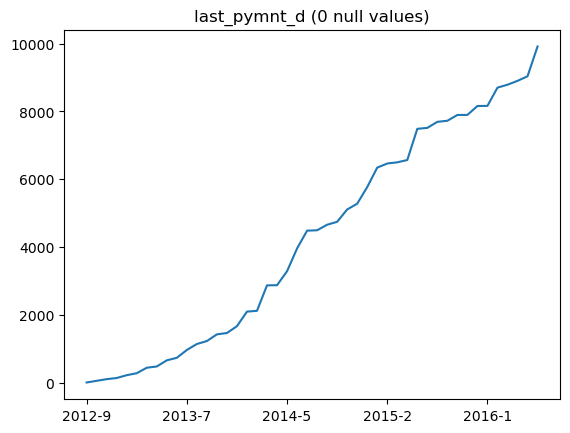

In [12]:
visualize_columns()

## Step 4 - Explore returns by loan grade

In [13]:
# Find the percentage of loans by grade, the default by grade,
# and the return of each grade
perc_by_grade = (final_data.grade.value_counts()*100/len(final_data)).sort_index()
default_by_grade = final_data.groupby("grade").apply(lambda x : (x.loan_status != "Fully Paid").sum()*100/len(x) )
ret_by_grade_OPT = final_data.groupby("grade").apply(lambda x : np.mean(x.ret_OPT)*100 )
ret_by_grade_PESS = final_data.groupby("grade").apply(lambda x : np.mean(x.ret_PESS)*100 )
ret_by_grade_INTa = final_data.groupby("grade").apply(lambda x : np.mean(x.ret_INTa)*100 )
ret_by_grade_INTb = final_data.groupby("grade").apply(lambda x : np.mean(x.ret_INTb)*100 )
ret_by_grade_INTc = final_data.groupby("grade").apply(lambda x : np.mean(x.ret_INTc)*100 )
int_rate_by_grade = final_data.groupby("grade").apply(lambda x : np.mean(x.int_rate))

combined = pd.DataFrame(perc_by_grade)
combined['default'] = default_by_grade
combined['int_rate'] = int_rate_by_grade
combined['return_OPT'] = ret_by_grade_OPT
combined['return_PESS'] = ret_by_grade_PESS
combined['return_INTa'] = ret_by_grade_INTa
combined['return_INTb'] = ret_by_grade_INTb
combined['return_INTc'] = ret_by_grade_INTc

combined

,grade,default,int_rate,return_OPT,return_PESS,return_INTa,return_INTb,return_INTc
A,14.946038,6.196167,7.611140,4.319868,1.674894,2.072680,3.772088,6.902302
B,30.995232,12.803296,11.700625,5.796100,1.973024,2.260937,3.967864,7.110963
C,26.796827,21.648976,14.949450,6.292312,0.911006,1.562123,3.242771,6.341383
D,16.390623,28.747051,17.950718,6.478591,0.182905,0.943375,2.585285,5.613925
E,7.265159,37.407200,20.990188,6.547270,-1.214214,-0.182770,1.394027,4.305778
F,2.923262,42.610966,24.064160,7.189898,-1.720230,-0.571463,0.977910,3.839441
G,0.682858,47.764531,25.683145,6.700130,-2.651790,-1.630345,-0.146390,2.597059


## Step 5 - Add multi-variable summaries, e.g. 2-vars at a time

In [14]:
seaborn.pairplot(combined)

## Step 6- K-means analysis

#### Remember to re-scale each dimension so that they have the same magnitude, whenever you use. 

In [15]:
# key columns for grade: int_rate, annual_inc, loan_amount, emp_length,
grade =  final_data.grade.to_numpy() # np_array
int_rate = final_data.int_rate.to_numpy()
annual_inc = final_data.annual_inc.to_numpy()
loan_amnt = final_data.loan_amnt.to_numpy()

# next convert the employment years into numerics
temp = final_data.emp_length.to_numpy()
emp_length = np.zeros(temp.shape[0])
for i in range(temp.shape[0]):
    if temp[i] is not None: # if this entry is not empty
        x = temp[i].split() # break a string into words
        output = x[0]
        if x[0] == '10+':
            output = 10
        if x[0] == '<':
            output = 0
        emp_length[i] = output
        
## finally we build a df storing these 6 columns
final_data.head()
df = final_data[['int_rate', 'annual_inc','loan_amnt']].copy()
df['emp_length'] = emp_length
df.head()

,int_rate,annual_inc,loan_amnt,emp_length
4,13.53,81500.0,20800.0,10.0
6,12.85,25000.0,3000.0,10.0
7,13.53,40000.0,12000.0,10.0
10,7.62,96500.0,12000.0,3.0
12,7.62,325000.0,28000.0,5.0


### Standardize dataset with (mean=0, variance=1) scale. 

Standardization is necessary as it removes the biases in the original variables. For example, when the data for each variable is collected on different units. The standardized variables will be unitless and have a similar variance. (Only in some cases, the dataset needs not to be standardized as the original variation in the dimensions of the dataset is important.)

In [16]:
from sklearn.preprocessing import StandardScaler
df_st =  StandardScaler().fit_transform(df) # this is an array
# see few rows of standardized dataset
pd.DataFrame(df_st, columns=df.columns).head()

,int_rate,annual_inc,loan_amnt,emp_length
0,-0.133167,0.204335,0.798635,1.134015
1,-0.287637,-1.093702,-1.397262,1.134015
2,-0.133167,-0.749091,-0.286977,1.134015
3,-1.475691,0.548946,-0.286977,-0.742211
4,-1.475691,5.798529,1.686864,-0.206146


In [17]:
from sklearn.cluster import KMeans
K=4 # enter your K here
kmeans = KMeans(n_clusters=K, random_state=0).fit(df_st)
labels = kmeans.labels_

import collections
collections.Counter(labels) # show the number of occurences of each of the labels

/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Counter({1: 67830, 2: 70330, 0: 23978, 3: 34389})

We recover the grading using k-means with k=4: The confusion matrix is consistent with the grading, e.g. most of A-loans are in the third  classes, while most of D/E/F/G loans are in the other 3 classes. B-loans are about uniformly distrubuted in all 4 classes.

In [18]:
K=4
ltr2num = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6}
table = np.zeros([7,K]) # row = letter grade, column = kmeans label
for j in range(df_st.shape[0]):
    table[ltr2num[grade[j]], labels[j]]+=1 # confusion matrix
for i in range(7):
    table[i,:] = np.round(table[i,:]*100/table[i,:].sum(), 1)
print("Confusion matrix: (in percentge, each row sums to 1):\n", table)

Confusion matrix: (in percentge, each row sums to 1):
 [[30.1 40.6 29.2  0. ]
 [14.  45.1 39.4  1.6]
 [ 9.  36.5 39.4 15.1]
 [ 4.3 24.2 38.7 32.8]
 [ 2.6  9.2 25.2 63. ]
 [ 1.1  2.1 15.  81.7]
 [ 2.1  0.1  6.6 91.2]]


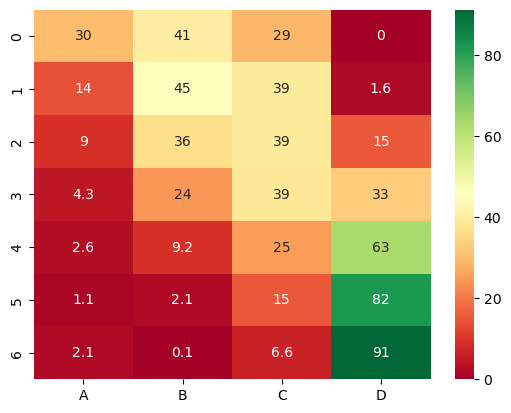

In [20]:
df_temp = pd.DataFrame(table, columns = ['A','B','C','D'])
# visulaize confusion matrix using heatmap
seaborn.heatmap(df_temp, annot=True, cmap='RdYlGn')
plt.show()

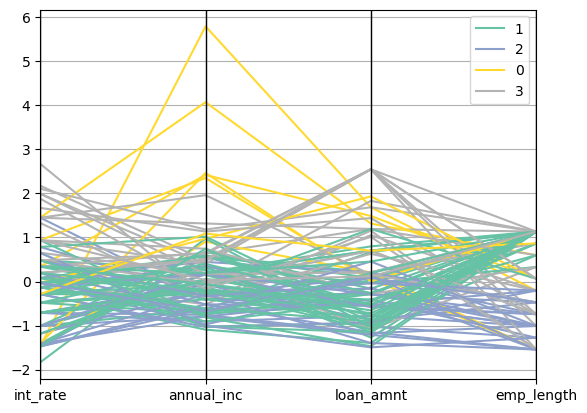

In [21]:
from pandas.plotting import parallel_coordinates
 
df_temp = pd.DataFrame(data=df_st, columns=list(df.columns)) # convert array to df
df_temp.head()
df_temp['label'] = labels

# Make the plot for the first 100 loans
parallel_coordinates(df_temp[0:100], 'label', colormap=plt.get_cmap("Set2")) # takes time
plt.show()

In [22]:
centroids = kmeans.cluster_centers_
print(centroids)

[[-0.66388443  1.67967626  1.10730764 -0.03209108]
 [-0.31346155 -0.21605857 -0.41116895  0.85038791]
 [-0.04629145 -0.43357102 -0.5128295  -0.98763332]
 [ 1.17390128  0.1473827   1.09165631  0.36390806]]


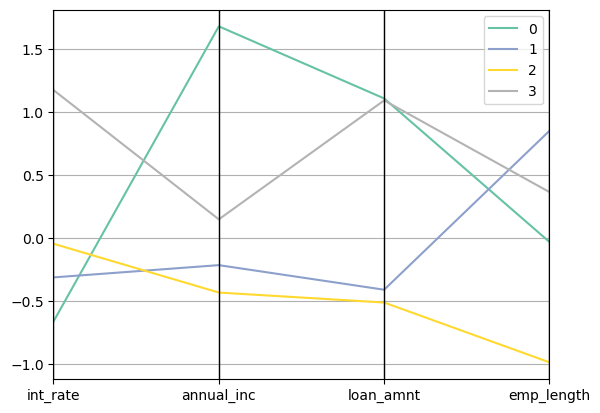

In [23]:
df_cent = pd.DataFrame(data=centroids, columns=list(df.columns)) # convert array to df
df_cent
rownos = pd.Series(range(0,8))
df_cent['label'] = rownos

parallel_coordinates(df_cent, 'label', colormap=plt.get_cmap("Set2")) # takes time
plt.show()

### Performance for different K: inertia (or within-cluster sum of squares). 
Let $c_k$ be the centroid of cluster $k$, the inertia is $$I=\sum_{k=1}^K \sum_{x\in C_k}(x-c_k)^2$$
Below we plot the inertia for the optimal clustering for each $K$ value. 

In [24]:
K_max = 10
inertia=np.zeros(K_max)
for K in range(1,K_max):
    kmeans = KMeans(n_clusters=K, random_state=0).fit(df_st)
    inertia[K]=kmeans.inertia_
    
idx = range(1,10)
plt.plot(idx,inertia[idx], 'r-',idx,inertia[idx], 'bo')
plt.legend('K')
plt.title('Inertia of the optimal K-clustering')

/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/clust

Text(0.5, 1.0, 'Inertia of the optimal K-clustering')

From the scree plot above, we see that K=4 or 3 is a reasonable choice.

## Step 7 - PCA
Run a principal component analysis

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(df_st)
print(pca.singular_values_,'\n')
compo = pca.components_
print("components:", compo)

[542.61758478 453.13468524] 

components: [[ 0.05503629  0.66514174  0.68018806  0.30315288]
 [-0.95430578  0.23886044 -0.17476153  0.04128645]]


In [26]:
pca_out = PCA().fit(df_st) # perform PCA
# get the component variance
# Proportion of Variance (from PC1 to PC6)
pca_out.explained_variance_ratio_

# get component loadings (correlation coefficient between original variables and the component) 
loadings = pca_out.components_
num_pc = pca_out.n_features_ # number prin compo
pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]
loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings)))
loadings_df['variable'] = df.columns.values
loadings_df = loadings_df.set_index('variable')
loadings_df

/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:101: FutureWarning: Attribute `n_features_` was deprecated in version 1.2 and will be removed in 1.4. Use `n_features_in_` instead.
  warnings.warn(msg, category=FutureWarning)


,PC1,PC2,PC3,PC4
variable,,,,
int_rate,0.055036,-0.954306,-0.020101,0.293031
annual_inc,0.665142,0.238860,0.230754,0.668793
loan_amnt,0.680188,-0.174762,0.200259,-0.683154
emp_length,0.303153,0.041286,-0.951969,0.012216


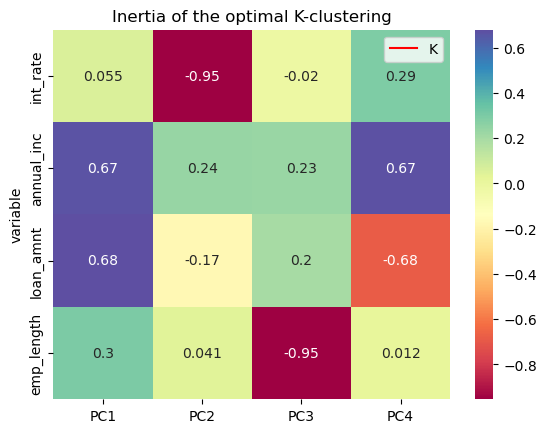

In [27]:
# get correlation matrix plot for loadings
ax = seaborn.heatmap(loadings_df, annot=True, cmap='Spectral')
plt.show()

### Biplots of interesting variables in the top PCs
Add a biplot of how the variables can be represented in the first two PCs.

In [28]:
pip install pca

Note: you may need to restart the kernel to use updated packages.


In [29]:
from pca import pca
model = pca(n_components=4)

# Fit transform
results = model.fit_transform(df_st)

# Plot explained variance
fig, ax = model.plot()

# Scatter first 2 PCs
fig, ax = model.scatter()

# Make biplot with the number of features
fig, ax = model.biplot(n_feat=4)

[pca] >Column labels are auto-completed.
[pca] >Row labels are auto-completed.
[pca] >The PCA reduction is performed on the [4] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[4]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


[scatterd] >INFO> Create scatterplot


[pca] >Plot PC1 vs PC2 with loadings.


[scatterd] >INFO> Create scatterplot


In [30]:
fig, ax = model.biplot3d(n_feat=3)

[pca] >Plot PC1 vs PC2 vs PC3 with loadings.


[scatterd] >INFO> Create scatterplot


In [31]:
# Prints out the top feature for each PC
print(results['topfeat'])

    PC feature   loading  type
0  PC1       3  0.680188  best
1  PC2       1 -0.954306  best
2  PC3       4 -0.951969  best
3  PC4       3 -0.683154  best
4  PC4       2  0.668793  weak


### Step 8 - Save data including returns information in a pickle for further analysis

In [42]:
## Remove the total_pymnt from the list of continuous features;
## this variable is highly predictive of the outcome
## but is not known at the time the loan is issued
#continuous_features = [i for i in continuous_features if i not in ["total_pymnt", "recoveries"]]

In [32]:
# Define the output path for the full pickle with returns info
#full_pickle_file = "/".join( ['.'] + ["PickleData"] + ["201213ret_data.pickle"] )
#pickle_file = "/".join(['.', "PickleData", "ret_data.pickle"])
#os.makedirs(os.path.dirname(pickle_file), exist_ok=True)
#full_pickle_file = "/".join( ['.'] + ["PickleData"] + ["ret_data.pickle"] )

#pickle.dump( [final_data, discrete_features, continuous_features, ret_cols], open(full_pickle_file, "wb") )